In [1]:
# set up notebook

# standard imports
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

First, we need to read in the data for the notebook. The name of the dataframe is based on the experimental system, two-hybrid. This experimental data features interaction data published in *A Human Map Kinase Interactome* by Bandyopadhyay S. et al. - 2010.$^{1}$  
In this type of experiment, there are two proteins: one that is categorized as the "bait" and the other as the "prey." For the sake of simplicity, we will leave this graph undirected.

In [2]:
#start = time.time()
two_h_df = pl.read_excel('Bandyopadhyay2010.xls')
#end = time.time()
#dur = end - start
#print(f"{dur} seconds")

The proteins in this graph will be nodes, and the edges are their interactions. To make this simpler, we will be using the Networkx module to build our graph. 

In [3]:
import networkx as nx

In [4]:
# look at the data
two_h_df.head

<bound method DataFrame.head of shape: (641, 5)
┌─────────────┬──────────────────────┬──────────────┬──────────────────────┬─────────────────────┐
│ BAIT_GENEID ┆ BAIT_OFFICIAL_SYMBOL ┆ PREY_GENE_ID ┆ PREY_OFFICIAL_SYMBOL ┆ EXPERIMENTAL_SYSTEM │
│ ---         ┆ ---                  ┆ ---          ┆ ---                  ┆ ---                 │
│ i64         ┆ str                  ┆ i64          ┆ str                  ┆ str                 │
╞═════════════╪══════════════════════╪══════════════╪══════════════════════╪═════════════════════╡
│ 1432        ┆ MAPK14               ┆ 166          ┆ AES                  ┆ Two-Hybrid          │
│ 1432        ┆ MAPK14               ┆ 1843         ┆ DUSP1                ┆ Two-Hybrid          │
│ 5879        ┆ RAC1                 ┆ 5058         ┆ PAK1                 ┆ Two-Hybrid          │
│ 998         ┆ CDC42                ┆ 396          ┆ ARHGDIA              ┆ Two-Hybrid          │
│ 1432        ┆ MAPK14               ┆ 2316         ┆ FLNA   

Before we start building our graph, we want to pull out all our nodes. In this case, those are the unique proteins in this data set.

In [5]:
#get all bait genes
bait_list = two_h_df['BAIT_GENEID']
#get all prey genes
prey_list = two_h_df['PREY_GENE_ID']
full_list = pl.concat([bait_list, prey_list])

unique_list = set(full_list.to_list())
print(f"The number of unique proteins is {len(unique_list)}.")

The number of unique proteins is 490.


Thinking ahead, if we want to add the official symbol as a node attribute, we'll need 2-tuples of the form (node, node_attribute_dict). Let's make a main dictionary quickly for later visualization.

In [6]:
official_sym_list = pl.concat([two_h_df['BAIT_OFFICIAL_SYMBOL'], two_h_df['PREY_OFFICIAL_SYMBOL']]).to_list()
full_list = full_list.to_list()
id_sym_dict = {}
for i in range(len(full_list)):
    gene_id = full_list[i]
    if gene_id not in id_sym_dict:
        id_sym_dict[gene_id] = official_sym_list[i]

Now let's make the graph itself. Note that the edges are from the original dataset of interactions and not from any unique list.

In [7]:
# create an empty digraph from the DiGraph class in NetworkX
g = nx.Graph()
# iterate over gene IDs in our unique list to add our nodes
for gene in unique_list:
    g.add_node(gene, symbol = id_sym_dict[gene])
# iterate through our original column to add the interactions as edges
for i in range(len(bait_list)):
    e = (bait_list[i], prey_list[i]) # define the edge from the row
    g.add_edge(*e) # add edge to the graph, we don't have weights

Let's look at our raw data graph, prior to any analysis.

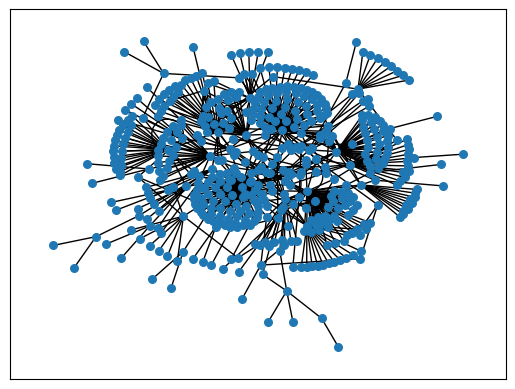

In [8]:
pos = nx.kamada_kawai_layout(g)
nx.draw_networkx(g, pos, node_size = 30, with_labels = False)
plt.show()

Definitely a bit of a mess, and even if we were to add back in those labels, it would be hard to see what's going on.  

Let's try to apply the MCODE algorithm. We need to first weight the vertices.

In [9]:
def get_subgraph_edges(main_graph: nx.Graph, subgraph_nodes):
    subgraph_edges = set()
    edges_list = list(main_graph.edges)
    for i in range(len(edges_list)):
        e = edges_list[i]
        for node in subgraph_nodes:
            if node == e[0] or node == e[1]:
                subgraph_edges.add(e)
    return subgraph_edges
    

def vertex_weighting(graph: nx.Graph):
    vertex_weights = {}
    for v in graph.nodes:
        #neighbors = graph.neighbors(v) # find all neighbors of the vertex
        neighbors = graph[v] #adjacency dictionary
        # make sub-graph with neighborhood nodes
        subgraph = nx.Graph()
        subgraph.add_nodes_from(neighbors)
        # add edges to the sub-graph from original graph
        edges = get_subgraph_edges(graph, list(subgraph.nodes))
        subgraph.add_edges_from(edges)
        subgraph.remove_edges_from(nx.selfloop_edges(subgraph))
        K = nx.k_core(subgraph) # highest k-core graph, networkx's k_core method returns the main core (with the largest core number by default)
        k = len(list(subgraph.nodes)) # highest k-core number
        d = nx.density(K) #density of K
        weight = k * d
        vertex_weights[v] = weight
    return vertex_weights

If we apply the above method, we complete stage one of the MCODE algorithm: Vertex Weighting. Below, we have stored the information in the variable W, following the nomenclature in the paper.

In [10]:
W = vertex_weighting(g) # store the vertex weights

Next, we want to proceed with prediction. The algorithm involves recursive movement from a seed vertex and includes vertices in the complex whose weight is above a threshold named the vertex weight percentage (VWP) parameter. Once a vertex is added to the complex, its neighbors are recursively check in the same way to see if they are a part of the same complex. If the VWP is closer to the weight of the seed vertex, it returns a smaller and denser network.

In [31]:
# try implementing with classes?

class MCODEComplexFinder:
    def __init__(self, graph: nx.Graph):
        self.graph = graph
        self.found_complexes = [] #list of sets perhaps?
        self.explored = set()
        self.W = vertex_weighting(self.graph)

    def find_complexes(self, VWP: float):
        vertices = list(self.W.items())
        n = len(vertices) # number of vertices
        sorted_vertices_by_weight = sorted(vertices, key = lambda k: k[1])
        iter = 0
        while (iter < n):
            seed, seed_weight = sorted_vertices_by_weight[n - 1 - iter]
            #print(seed)
            self.find_mcc(VWP, set(), self.found_complexes, self.explored, seed)
            iter+=1

    def find_mcc(self, VWP, current_complex, found_complexes, explored, seed_node):
        if seed_node in explored:
            return
        if current_complex in self.found_complexes:
            return
        self.explored.add(seed_node)
        current_complex.add(seed_node)
        neighbors = self.graph[seed_node]
        for n in neighbors:
            if self.W[n] > (self.W[seed_node]  * (1 - VWP)):
                current_complex.add(n)
                self.find_mcc(VWP, current_complex, self.found_complexes, self.explored, n)
        self.found_complexes.append(current_complex)
                

In [12]:
def find_mcode_complex (graph: nx.Graph, VWP: float, explored: set, m_complex: set, weights: dict, seed):
    if seed in explored:
        print(f"explored {seed}")
        #print(m_complex)
        return m_complex
    explored.add(seed)
    print(explored)
    m_complex.add(seed)
    neighbors = graph[seed] # find neighbors
    #m_complex_add = m_complex # to add to if we find a vertex weighted appropriately
    for n in neighbors:
        #print(f"neighbor weight: {weights[n]} and seed weight: {weights[seed]}")
        if weights[n] > (weights[seed] * (1 - VWP)):
            m_complex.add(n)
            print(m_complex)
            find_mcode_complex(graph, VWP, explored, m_complex, weights, n)
            

In [13]:
nodes = list(g.nodes)
seed = max(W, key = lambda k: W[k])
print(seed)
c = find_mcode_complex(g, 0.2, set(), set(), W, seed)
#print(c)
W[10987]

10987
{10987}


96.0

In [32]:
m = MCODEComplexFinder(g)
m.find_complexes(0.1)
len(m.found_complexes)
#something went wrong here

490

In [27]:
for c in m.found_complexes:
    if len(c) > 1:
        print(c)

{6721, 65125, 8491, 10987, 7532, 7534, 11183, 4208, 4209}
{6721, 65125, 8491, 10987, 7532, 7534, 11183, 4208, 4209}
{3728, 1495}
{3728, 1495}
{9994, 6667, 22926, 408, 7329, 10401, 1447, 55729, 6711, 4800, 6721, 4802, 4801, 7750, 23126, 23390, 9063, 1385, 8554, 10987, 3309, 7791, 2804}
{9994, 6667, 22926, 408, 7329, 10401, 1447, 55729, 6711, 4800, 6721, 4802, 4801, 7750, 23126, 23390, 9063, 1385, 8554, 10987, 3309, 7791, 2804}
{9994, 6667, 22926, 408, 7329, 10401, 1447, 55729, 6711, 4800, 6721, 4802, 4801, 7750, 23126, 23390, 9063, 1385, 8554, 10987, 3309, 7791, 2804}
{9994, 6667, 22926, 408, 7329, 10401, 1447, 55729, 6711, 4800, 6721, 4802, 4801, 7750, 23126, 23390, 9063, 1385, 8554, 10987, 3309, 7791, 2804}
{9994, 6667, 22926, 408, 7329, 10401, 1447, 55729, 6711, 4800, 6721, 4802, 4801, 7750, 23126, 23390, 9063, 1385, 8554, 10987, 3309, 7791, 2804}
{10114, 9994, 9869, 22926, 5903, 64397, 7329, 10401, 55729, 204851, 26036, 2752, 6721, 7750, 23126, 23384, 9063, 1385, 8554, 2804, 54778}


below is some troubleshooting work

below also does not work

In [16]:
def find_complexes (graph: nx.Graph, VWP: float, weights:dict):
    seen = set()
    complexes = []
    for node in list(graph.nodes):
        #print(node)
        is_seen = node in seen
        #print(is_seen)
        if node not in seen:
            C = find_mcode_complex(graph, VWP, seen, [], weights, node)
            #print(C)
            #seen.update(explored)
            seen.add(node)
            if C is not None:
                complexes.append(C) # becomes a nested list
    return complexes